# Air Quality Prediction and Environmental Analytics System
### IBM SkillsBuild Data Analytics with AI Academic Internship Program
**Conducted by BharatCares in association with AICTE**

---
- **Student Name:** [YOUR NAME]
- **USN / Roll Number:** [YOUR USN]
- **College / Institute:** [YOUR COLLEGE]
- **University:** [YOUR UNIVERSITY]
- **Department:** [YOUR DEPARTMENT]
- **Academic Year:** 2026
---


## 1. Problem Statement

Urban air pollution is one of the most critical environmental and public health challenges globally. Carbon monoxide ($	ext{CO}$), a colorless, odorless, and toxic gas produced primarily by incomplete combustion of fossil fuels in vehicular traffic and industrial processes, poses severe health hazards. Prolonged exposure impairs oxygen delivery in the human bloodstream, exacerbating cardiovascular and respiratory illnesses.

While specialized certified reference analyzers provide highly accurate concentration readings, their high capital expenditure and maintenance requirements limit spatial coverage. Low-cost multi-sensor chemical arrays provide dense spatial telemetry but suffer from cross-sensitivity to humidity and temperature, non-linear sensor response, and calibration drift.

The objective of this project is to develop an **end-to-end machine learning regression system** that accurately estimates ground-truth Carbon Monoxide ($	ext{CO(GT)}$) concentrations (in $	ext{mg/m}^3$) from chemical sensor array responses and ambient meteorological variables, while establishing rigorous data quality, imputation, and validation standards.


## 2. Objectives

1. **Ingest and Validate Dataset:** Verify structure, encoding, semicolons, and decimal formatting of the UCI Air Quality dataset.
2. **Data Cleaning & Handling -200 Missing Values:** Detect and replace the `-200` sensor error flag with `NaN`, and evaluate missingness profiles.
3. **Exploratory Data Analysis (EDA):** Analyze distributions, pollutant cross-correlations, and meteorological influences (temperature, relative humidity).
4. **Feature Selection:** Establish a robust 11-feature predictor set while excluding heavily missing features ($	ext{NMHC(GT)}$).
5. **Leakage-Free Preprocessing:** Fit missing-value imputers (median) and feature scalers (`StandardScaler`) exclusively on the training split ($80\%$).
6. **Model Training & Comparison:** Implement Ordinary Least Squares `LinearRegression` as the primary interpretable model, and compare with `RandomForestRegressor`.
7. **Rigorous Evaluation:** Quantify model performance using $R^2$, Mean Absolute Error ($	ext{MAE}$), and Root Mean Squared Error ($	ext{RMSE}$).
8. **Diagnostic Verification:** Examine residual distributions, homoscedasticity, and standardized feature coefficients.


## 3. Dataset Description

The dataset used in this study is the **Air Quality Dataset** from the **UCI Machine Learning Repository**:
- **Source Citation:** Vito, S. (2008). Air Quality. UCI Machine Learning Repository. https://doi.org/10.24432/C59K5F
- **Recording Location:** A heavily polluted road-level area within an Italian city.
- **Recording Window:** March 2004 to April 2005 (1 full year of continuous hourly recordings, 9,357 valid observation timestamps).
- **Measurement Setup:** Field deployment of an array of 5 metal oxide chemical sensors alongside co-located reference analyzers for ground-truth verification.

### Substantive Variables (15 Columns):
1. `Date`: Date of measurement ($	ext{DD/MM/YYYY}$)
2. `Time`: Time of measurement ($	ext{HH.mm.ss}$)
3. `CO(GT)`: True hourly averaged Carbon Monoxide concentration in $	ext{mg/m}^3$ (**Target Variable**)
4. `PT08.S1(CO)`: Tin oxide sensor response (nominally CO targeted)
5. `NMHC(GT)`: Non-Metanic HydroCarbons concentration in $\mu	ext{g/m}^3$ (reference analyzer)
6. `C6H6(GT)`: True hourly averaged Benzene concentration in $\mu	ext{g/m}^3$
7. `PT08.S2(NMHC)`: Titania sensor response (nominally NMHC targeted)
8. `NOx(GT)`: True hourly averaged $	ext{NO}_x$ concentration in $	ext{ppb}$
9. `PT08.S3(NOx)`: Tungsten oxide sensor response (nominally $	ext{NO}_x$ targeted)
10. `NO2(GT)`: True hourly averaged $	ext{NO}_2$ concentration in $\mu	ext{g/m}^3$
11. `PT08.S4(NO2)`: Tungsten oxide sensor response (nominally $	ext{NO}_2$ targeted)
12. `PT08.S5(O3)`: Indium oxide sensor response (nominally $	ext{O}_3$ targeted)
13. `T`: Ambient Temperature in $^\circ	ext{C}$
14. `RH`: Relative Humidity ($\%$)
15. `AH`: Absolute Humidity


## 4. Import Libraries

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Scikit-Learn tools
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Configure visual styling
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10
pd.set_option('display.max_columns', 20)

print("All libraries successfully imported.")


All libraries successfully imported.


## 5. Load Dataset

In [2]:
data_path = os.path.join('data', 'AirQualityUCI.csv')

# Load raw CSV with semicolon delimiter and comma decimal separator
df_raw = pd.read_csv(data_path, sep=';', decimal=',')
print(f"Raw dataset successfully loaded. Raw Shape: {df_raw.shape}")


Raw dataset successfully loaded. Raw Shape: (9471, 17)


## 6. Dataset Inspection

In [3]:
print("First 5 rows of raw dataset:")
display(df_raw.head())

print("\nRaw Columns:")
print(df_raw.columns.tolist())

print("\nData Types & Non-Null Information:")
df_raw.info()


First 5 rows of raw dataset:


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,NaN,NaN
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,NaN,NaN
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,NaN,NaN
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,NaN,NaN
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,NaN,NaN



Raw Columns:
['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH', 'Unnamed: 15', 'Unnamed: 16']

Data Types & Non-Null Information:
<class 'pandas.DataFrame'>
RangeIndex: 9471 entries, 0 to 9470
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   str    
 1   Time           9357 non-null   str    
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   float64
 4   NMHC(GT)       9357 non-null   float64
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   float64
 7   NOx(GT)        9357 non-null   float64
 8   PT08.S3(NOx)   9357 non-null   float64
 9   NO2(GT)        9357 non-null   float64
 10  PT08.S4(NO2)   9357 non-null   float64
 11  PT08.S5(O3)    9357 non-null   float64
 12  T              9357 non-null   flo

## 7. Data Cleaning

In [4]:
# Select only the first 15 substantive columns (dropping trailing empty columns Unnamed: 15 & 16)
df = df_raw.iloc[:, :15].copy()

# Remove completely empty rows (rows where Date is NaN)
df = df.dropna(how='all')
df = df[df['Date'].notna()].copy()

print(f"Dataset shape after removing trailing columns and blank rows: {df.shape}")
print(f"Valid observations retained: {len(df)}")


Dataset shape after removing trailing columns and blank rows: (9357, 15)
Valid observations retained: 9357


## 8. Missing Value Analysis
The UCI Air Quality repository documentation specifies that **`-200`** is used as an error flag for missing sensor/analyzer readings.
We now replace `-200` with `np.nan` and analyze missingness percentages across all features.


,Total Records,Missing Count,Missing Percentage (%)
NMHC(GT),9357,8443,90.23
CO(GT),9357,1683,17.99
NO2(GT),9357,1642,17.55
NOx(GT),9357,1639,17.52
PT08.S1(CO),9357,366,3.91
PT08.S2(NMHC),9357,366,3.91
C6H6(GT),9357,366,3.91
PT08.S3(NOx),9357,366,3.91
PT08.S4(NO2),9357,366,3.91
PT08.S5(O3),9357,366,3.91


C:\Users\donth\AppData\Local\Temp\ipykernel_23424\3453468737.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_stats.index, y=missing_stats['Missing Percentage (%)'], palette='Reds_r')


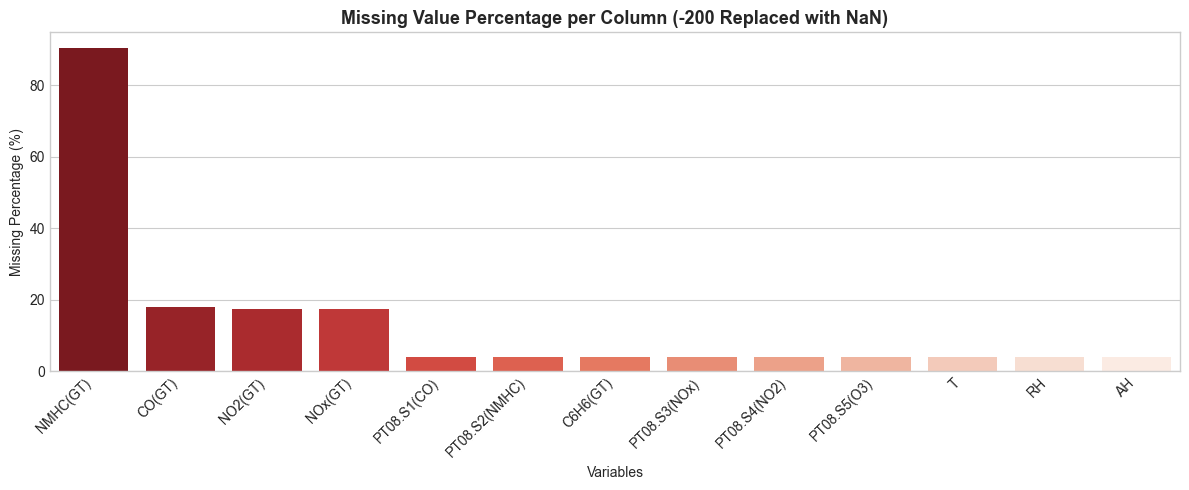

Key Observation: NMHC(GT) exhibits 90.23% missing values. It will be excluded from predictive modeling.


In [5]:
# Replace -200 with NaN across all columns
df = df.replace(-200, np.nan).replace(-200.0, np.nan)

# Compute missingness counts and percentages
numeric_cols = [c for c in df.columns if c not in ['Date', 'Time']]
missing_stats = pd.DataFrame({
    'Total Records': len(df),
    'Missing Count': df[numeric_cols].isna().sum(),
    'Missing Percentage (%)': (df[numeric_cols].isna().mean() * 100).round(2)
}).sort_values(by='Missing Percentage (%)', ascending=False)

display(missing_stats)

# Visualizing Missingness
plt.figure(figsize=(12, 5))
sns.barplot(x=missing_stats.index, y=missing_stats['Missing Percentage (%)'], palette='Reds_r')
plt.xticks(rotation=45, ha='right')
plt.title("Missing Value Percentage per Column (-200 Replaced with NaN)", fontsize=13, fontweight='bold')
plt.ylabel("Missing Percentage (%)")
plt.xlabel("Variables")
plt.tight_layout()
plt.show()

print("Key Observation: NMHC(GT) exhibits 90.23% missing values. It will be excluded from predictive modeling.")


## 9. Exploratory Data Analysis (EDA)

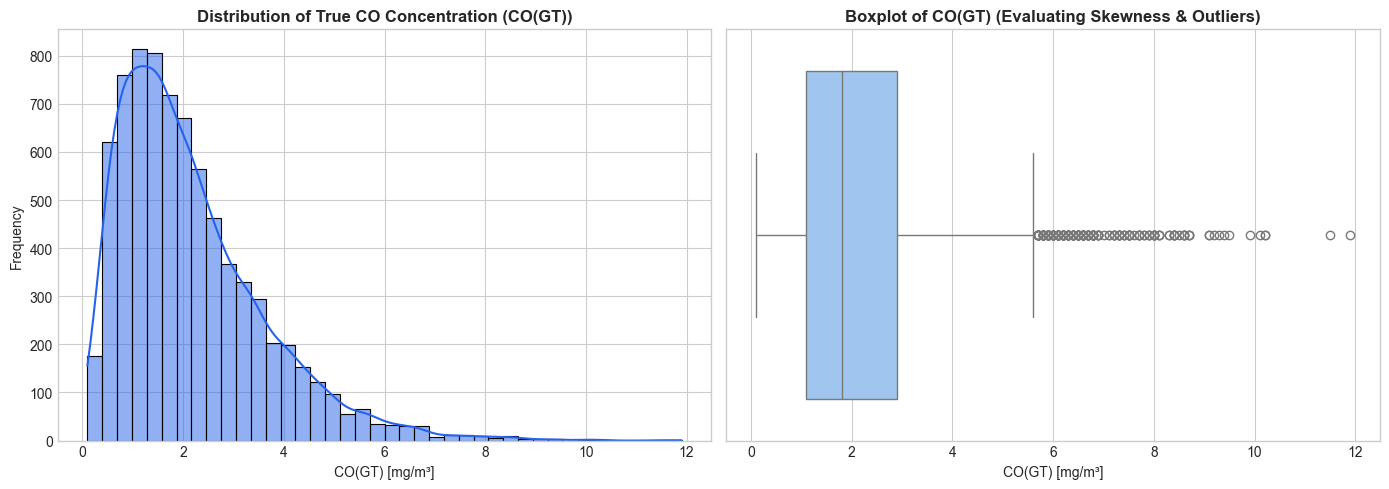

In [6]:
# 1. Target Variable Distribution: CO(GT)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['CO(GT)'].dropna(), kde=True, color='#2563eb', bins=40, ax=axes[0])
axes[0].set_title("Distribution of True CO Concentration (CO(GT))", fontweight='bold')
axes[0].set_xlabel("CO(GT) [mg/m³]")
axes[0].set_ylabel("Frequency")

sns.boxplot(x=df['CO(GT)'].dropna(), color='#93c5fd', ax=axes[1])
axes[1].set_title("Boxplot of CO(GT) (Evaluating Skewness & Outliers)", fontweight='bold')
axes[1].set_xlabel("CO(GT) [mg/m³]")

plt.tight_layout()
plt.show()


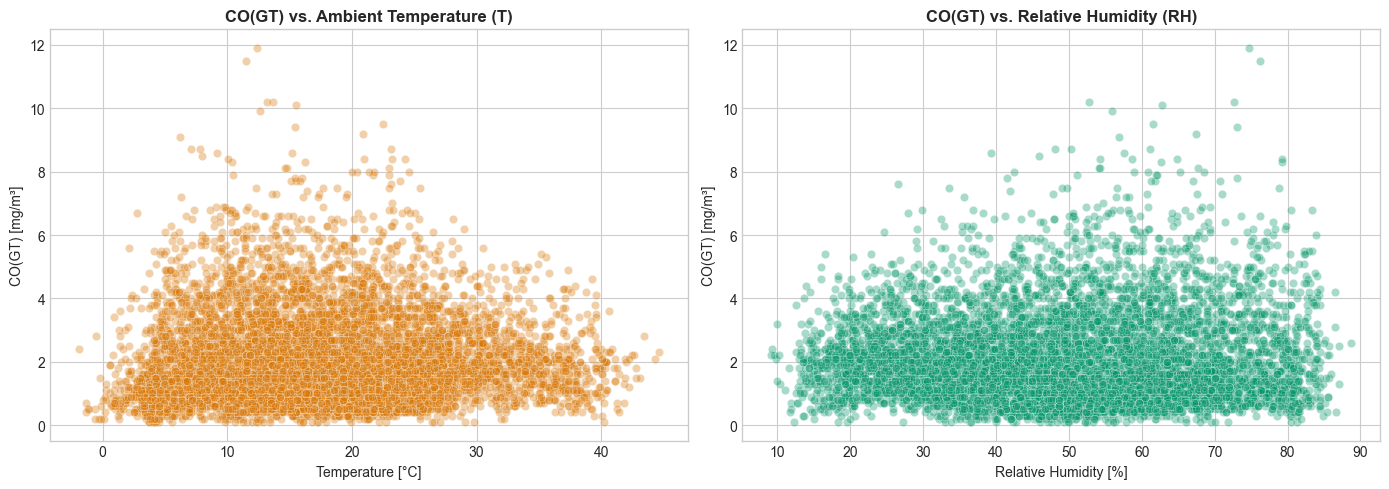

In [7]:
# 2. Relationship with Meteorological Factors (Temperature & Humidity)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

clean_weather = df[['T', 'RH', 'CO(GT)']].dropna()

sns.scatterplot(x='T', y='CO(GT)', data=clean_weather, alpha=0.35, color='#d97706', ax=axes[0])
axes[0].set_title("CO(GT) vs. Ambient Temperature (T)", fontweight='bold')
axes[0].set_xlabel("Temperature [°C]")
axes[0].set_ylabel("CO(GT) [mg/m³]")

sns.scatterplot(x='RH', y='CO(GT)', data=clean_weather, alpha=0.35, color='#059669', ax=axes[1])
axes[1].set_title("CO(GT) vs. Relative Humidity (RH)", fontweight='bold')
axes[1].set_xlabel("Relative Humidity [%]")
axes[1].set_ylabel("CO(GT) [mg/m³]")

plt.tight_layout()
plt.show()


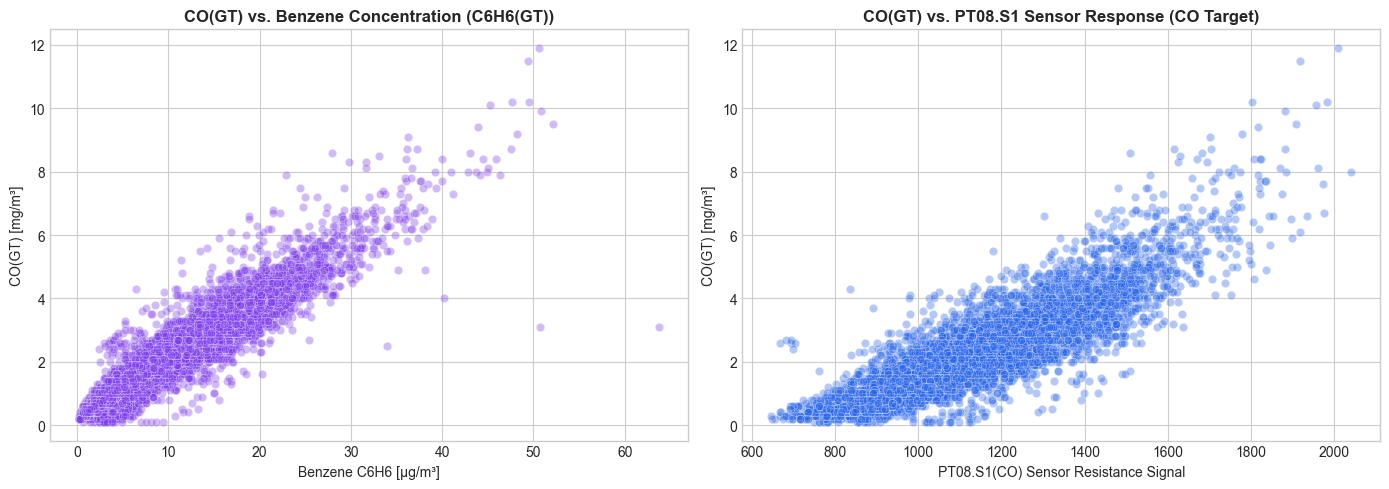

In [8]:
# 3. Relationship with Co-pollutants and Sensor Responses
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

clean_sensors = df[['C6H6(GT)', 'PT08.S1(CO)', 'CO(GT)']].dropna()

sns.scatterplot(x='C6H6(GT)', y='CO(GT)', data=clean_sensors, alpha=0.35, color='#7c3aed', ax=axes[0])
axes[0].set_title("CO(GT) vs. Benzene Concentration (C6H6(GT))", fontweight='bold')
axes[0].set_xlabel("Benzene C6H6 [µg/m³]")
axes[0].set_ylabel("CO(GT) [mg/m³]")

sns.scatterplot(x='PT08.S1(CO)', y='CO(GT)', data=clean_sensors, alpha=0.35, color='#2563eb', ax=axes[1])
axes[1].set_title("CO(GT) vs. PT08.S1 Sensor Response (CO Target)", fontweight='bold')
axes[1].set_xlabel("PT08.S1(CO) Sensor Resistance Signal")
axes[1].set_ylabel("CO(GT) [mg/m³]")

plt.tight_layout()
plt.show()


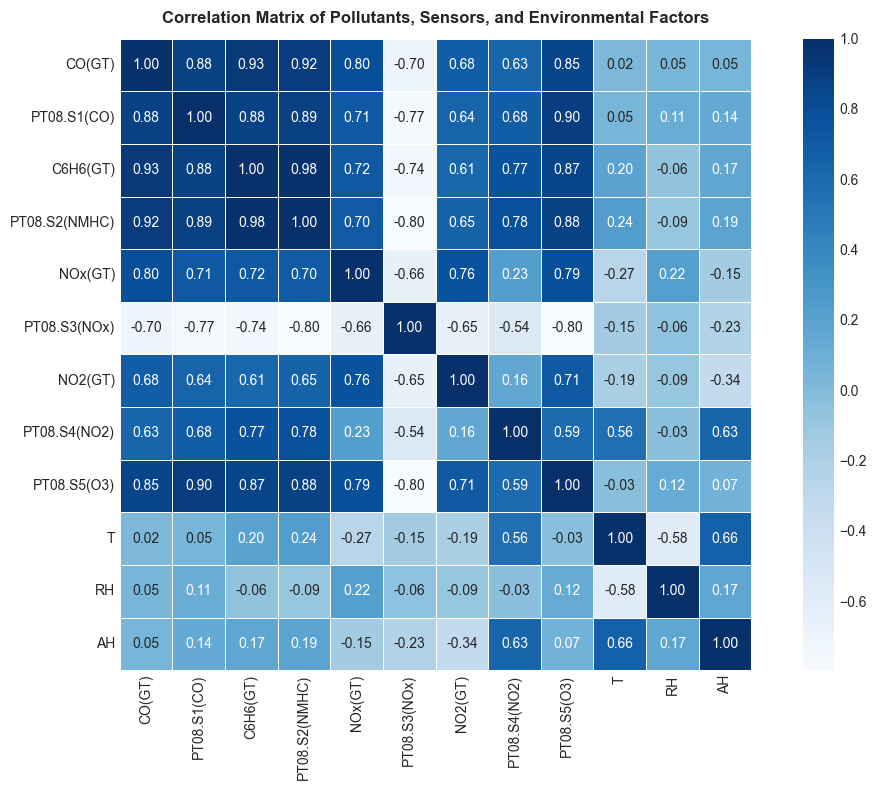

In [9]:
# 4. Correlation Heatmap
plt.figure(figsize=(11, 8))
selected_corr_cols = ['CO(GT)', 'PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 
                      'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']
corr_matrix = df[selected_corr_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='Blues', cbar=True, square=True, linewidths=0.5)
plt.title("Correlation Matrix of Pollutants, Sensors, and Environmental Factors", fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()


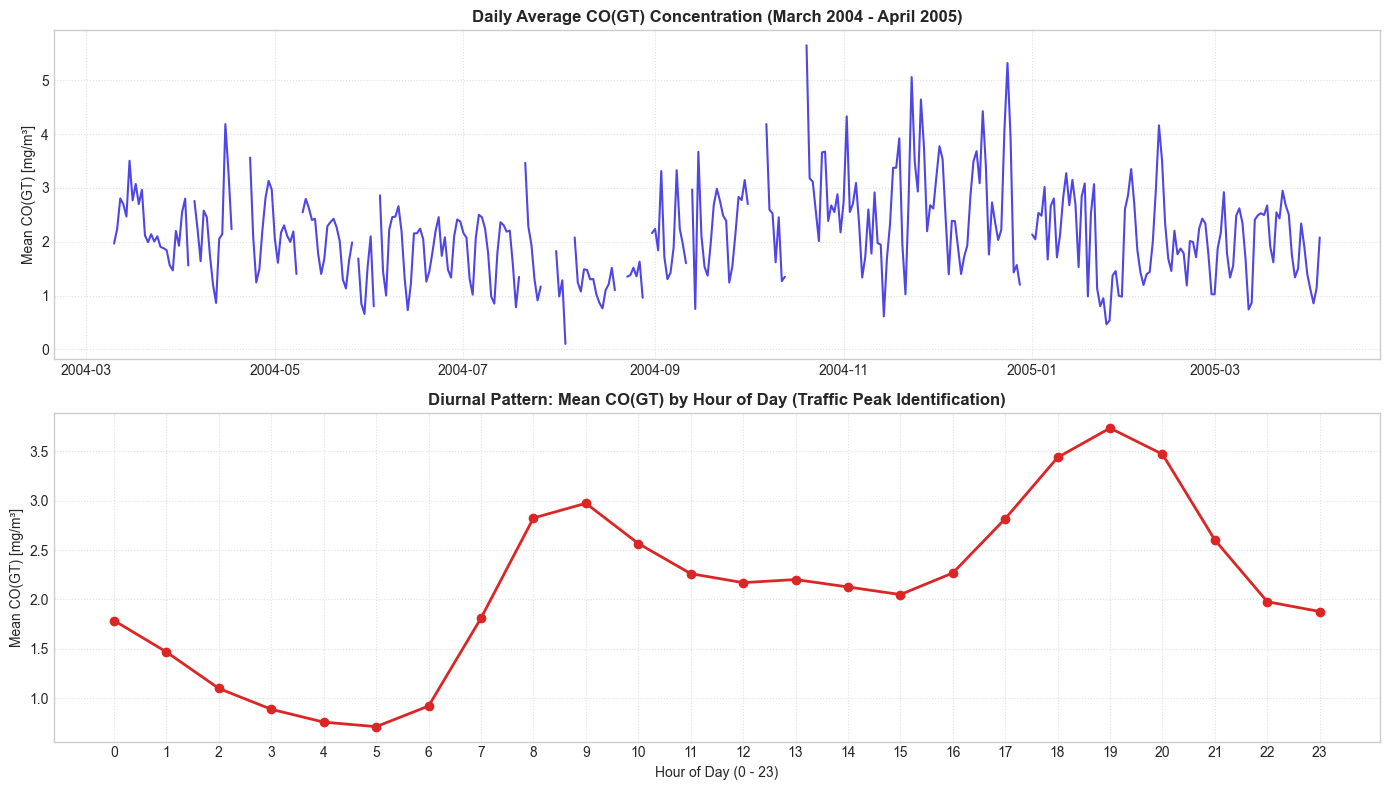

In [10]:
# 5. Temporal Trend Analysis
df['DateTime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'].str.replace('.', ':', regex=False),
    format='%d/%m/%Y %H:%M:%S',
    errors='coerce'
)
df['Hour'] = df['DateTime'].dt.hour
df['Month'] = df['DateTime'].dt.month

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Daily average CO time series
daily_co = df.set_index('DateTime')['CO(GT)'].resample('D').mean()
axes[0].plot(daily_co.index, daily_co.values, color='#4f46e5', lw=1.5)
axes[0].set_title("Daily Average CO(GT) Concentration (March 2004 - April 2005)", fontweight='bold')
axes[0].set_ylabel("Mean CO(GT) [mg/m³]")
axes[0].grid(True, linestyle=':', alpha=0.6)

# Diurnal (Hourly) Cycle
hourly_co = df.groupby('Hour')['CO(GT)'].mean()
axes[1].plot(hourly_co.index, hourly_co.values, marker='o', color='#dc2626', lw=2)
axes[1].set_title("Diurnal Pattern: Mean CO(GT) by Hour of Day (Traffic Peak Identification)", fontweight='bold')
axes[1].set_xlabel("Hour of Day (0 - 23)")
axes[1].set_ylabel("Mean CO(GT) [mg/m³]")
axes[1].set_xticks(range(0, 24))
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


## 10. Feature Selection
We establish the candidate predictor matrix $X$ and target vector $y$:
- **Target:** `CO(GT)`
- **Excluded Features:**
  - `NMHC(GT)`: Excluded due to excessive missingness ($90.23\%$).
  - `CO(GT)`: The target variable itself cannot be used as an input.
  - Raw `Date` & `Time`: Excluded from numerical feature vector to avoid spurious index memorization.
- **Selected Predictor Features (11):**
  1. `PT08.S1(CO)`
  2. `C6H6(GT)`
  3. `PT08.S2(NMHC)`
  4. `NOx(GT)`
  5. `PT08.S3(NOx)`
  6. `NO2(GT)`
  7. `PT08.S4(NO2)`
  8. `PT08.S5(O3)`
  9. `T`
  10. `RH`
  11. `AH`

For supervised modeling, records without ground-truth target `CO(GT)` labels cannot be used for training or quantitative evaluation, and are filtered.


In [11]:
features = [
    'PT08.S1(CO)',
    'C6H6(GT)',
    'PT08.S2(NMHC)',
    'NOx(GT)',
    'PT08.S3(NOx)',
    'NO2(GT)',
    'PT08.S4(NO2)',
    'PT08.S5(O3)',
    'T',
    'RH',
    'AH'
]
target = 'CO(GT)'

# Retain observations with ground truth target labels
df_supervised = df.dropna(subset=[target]).copy()
print(f"Labeled dataset size for supervised training: {df_supervised.shape[0]} rows")

X = df_supervised[features].copy()
y = df_supervised[target].copy()


Labeled dataset size for supervised training: 7674 rows


## 11. Train / Test Split
To evaluate generalization ability honestly, we perform an $80/20$ train-test split with `random_state=42`.


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Training feature set shape: {X_train.shape}")
print(f"Testing feature set shape:  {X_test.shape}")
print(f"Training target size:       {y_train.shape[0]}")
print(f"Testing target size:        {y_test.shape[0]}")


Training feature set shape: (6139, 11)
Testing feature set shape:  (1535, 11)
Training target size:       6139
Testing target size:        1535


## 12. Preprocessing: Imputation & Scaling (Zero Data Leakage)
**Strict Preprocessing Protocol:**
- `SimpleImputer(strategy='median')`: Median is robust against sensor spikes and skewed distributions.
- `StandardScaler()`: Standardizes feature scales to $\mu = 0, \sigma = 1$, enabling direct interpretation of linear regression coefficients.
- **Critical:** Both `imputer` and `scaler` are fit **ONLY** on `X_train`. `X_test` is transformed using the parameters learned from `X_train`, preventing data leakage.


In [13]:
# 1. Fit Imputer ONLY on X_train
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)

# 2. Fit Scaler ONLY on X_train_imp
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled = scaler.transform(X_test_imp)

print("Preprocessing pipeline successfully fitted on training data and applied to test split.")


Preprocessing pipeline successfully fitted on training data and applied to test split.


## 13. Model Training
We train Ordinary Least Squares `LinearRegression` as the primary interpretable predictive model, and train a benchmark `RandomForestRegressor` for non-linear comparison.


In [14]:
# Primary Model: Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
print("Linear Regression model successfully trained.")

# Benchmark Model: Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)
print("Random Forest Regressor benchmark successfully trained.")


Linear Regression model successfully trained.


Random Forest Regressor benchmark successfully trained.


## 14. Predictions

In [15]:
# Predictions on Train and Test sets
y_train_pred_lr = lr_model.predict(X_train_scaled)
y_test_pred_lr = lr_model.predict(X_test_scaled)

y_test_pred_rf = rf_model.predict(X_test_scaled)
print("Predictions generated on test sets.")


Predictions generated on test sets.


## 15. Model Evaluation
We compute the actual calculated performance metrics:
- **$R^2$ (Coefficient of Determination)**: Proportion of variance in $	ext{CO(GT)}$ explained by the model.
- **$	ext{MAE}$ (Mean Absolute Error)**: Average absolute magnitude of prediction errors in $	ext{mg/m}^3$.
- **$	ext{RMSE}$ (Root Mean Squared Error)**: Standard deviation of residuals, penalizing larger deviations in $	ext{mg/m}^3$.


In [16]:
# Actual metrics computation
r2_train_lr = r2_score(y_train, y_train_pred_lr)
r2_test_lr = r2_score(y_test, y_test_pred_lr)
mae_test_lr = mean_absolute_error(y_test, y_test_pred_lr)
rmse_test_lr = np.sqrt(mean_squared_error(y_test, y_test_pred_lr))

r2_test_rf = r2_score(y_test, y_test_pred_rf)
mae_test_rf = mean_absolute_error(y_test, y_test_pred_rf)
rmse_test_rf = np.sqrt(mean_squared_error(y_test, y_test_pred_rf))

results_df = pd.DataFrame({
    'Model Architecture': ['Linear Regression (Primary)', 'Random Forest Regressor (Benchmark)'],
    'Train R²': [f"{r2_train_lr:.4f}", f"{r2_score(y_train, rf_model.predict(X_train_scaled)):.4f}"],
    'Test R²': [f"{r2_test_lr:.4f}", f"{r2_test_rf:.4f}"],
    'Test MAE (mg/m³)': [f"{mae_test_lr:.4f}", f"{mae_test_rf:.4f}"],
    'Test RMSE (mg/m³)': [f"{rmse_test_lr:.4f}", f"{rmse_test_rf:.4f}"]
})

display(results_df)


,Model Architecture,Train R²,Test R²,Test MAE (mg/m³),Test RMSE (mg/m³)
0,Linear Regression (Primary),0.8866,0.8888,0.3080,0.4813
1,Random Forest Regressor (Benchmark),0.9772,0.9239,0.2516,0.3982


## 16. Actual vs Predicted Analysis

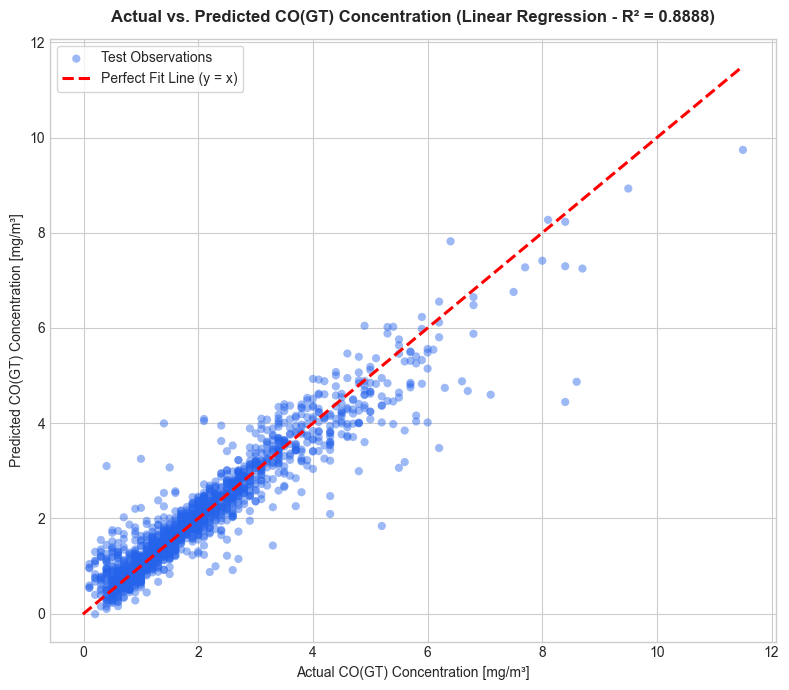

In [17]:
plt.figure(figsize=(8, 7))
plt.scatter(y_test, y_test_pred_lr, alpha=0.45, color='#2563eb', edgecolors='none', s=35, label='Test Observations')
min_val = min(y_test.min(), y_test_pred_lr.min())
max_val = max(y_test.max(), y_test_pred_lr.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2.2, label='Perfect Fit Line (y = x)')

plt.title(f"Actual vs. Predicted CO(GT) Concentration (Linear Regression - R² = {r2_test_lr:.4f})", fontsize=12, fontweight='bold', pad=12)
plt.xlabel("Actual CO(GT) Concentration [mg/m³]", fontsize=10)
plt.ylabel("Predicted CO(GT) Concentration [mg/m³]", fontsize=10)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()


## 17. Residual Analysis

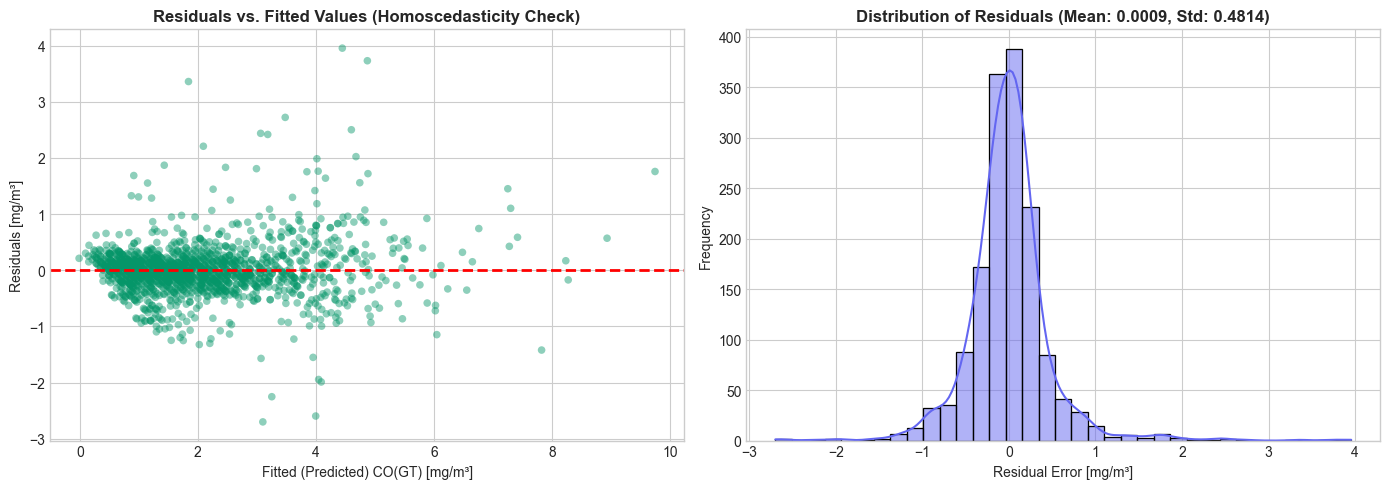

In [18]:
residuals_lr = y_test - y_test_pred_lr

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs Predicted
axes[0].scatter(y_test_pred_lr, residuals_lr, alpha=0.45, color='#059669', edgecolors='none', s=30)
axes[0].axhline(0, color='red', linestyle='--', lw=2)
axes[0].set_title("Residuals vs. Fitted Values (Homoscedasticity Check)", fontweight='bold')
axes[0].set_xlabel("Fitted (Predicted) CO(GT) [mg/m³]")
axes[0].set_ylabel("Residuals [mg/m³]")

# Residual Distribution
sns.histplot(residuals_lr, kde=True, color='#6366f1', bins=35, ax=axes[1])
axes[1].set_title(f"Distribution of Residuals (Mean: {residuals_lr.mean():.4f}, Std: {residuals_lr.std():.4f})", fontweight='bold')
axes[1].set_xlabel("Residual Error [mg/m³]")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()


## 18. Feature Importance & Coefficients

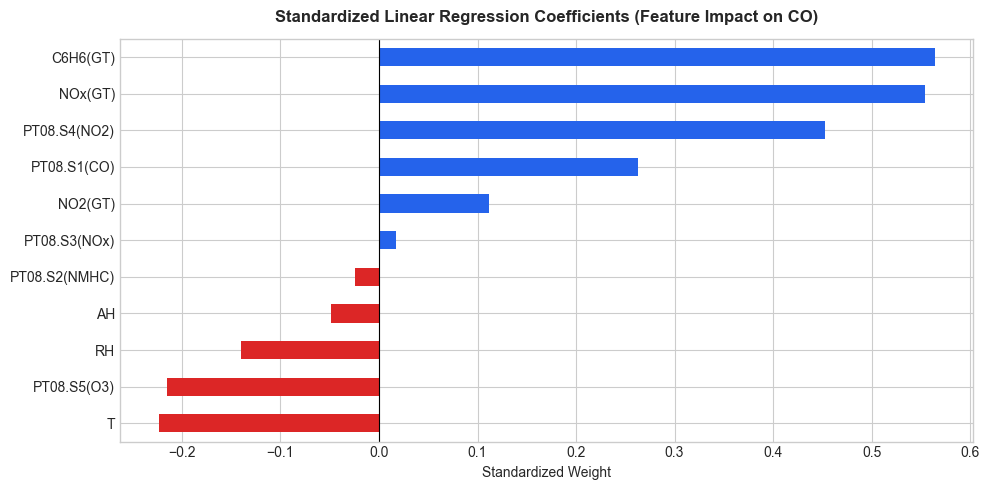

Feature Coefficients Breakdown:
  T              : -0.2237
  PT08.S5(O3)    : -0.2153
  RH             : -0.1396
  AH             : -0.0484
  PT08.S2(NMHC)  : -0.0247
  PT08.S3(NOx)   : +0.0171
  NO2(GT)        : +0.1116
  PT08.S1(CO)    : +0.2627
  PT08.S4(NO2)   : +0.4528
  NOx(GT)        : +0.5545
  C6H6(GT)       : +0.5639
  Intercept      : 2.1663


In [19]:
coef_series = pd.Series(lr_model.coef_, index=features).sort_values()

plt.figure(figsize=(10, 5))
colors = ['#dc2626' if c < 0 else '#2563eb' for c in coef_series.values]
coef_series.plot(kind='barh', color=colors)
plt.axvline(0, color='black', linestyle='-', lw=0.8)
plt.title("Standardized Linear Regression Coefficients (Feature Impact on CO)", fontsize=12, fontweight='bold', pad=12)
plt.xlabel("Standardized Weight")
plt.tight_layout()
plt.show()

print("Feature Coefficients Breakdown:")
for feat, val in coef_series.items():
    print(f"  {feat:<15}: {val:+.4f}")
print(f"  Intercept      : {lr_model.intercept_:.4f}")


## 19. Sample Prediction Pipeline

In [20]:
# Sample realistic observation (median values from dataset)
sample_sensor_input = {
    'PT08.S1(CO)': 1063.0,
    'C6H6(GT)': 8.2,
    'PT08.S2(NMHC)': 909.0,
    'NOx(GT)': 180.0,
    'PT08.S3(NOx)': 795.0,
    'NO2(GT)': 109.0,
    'PT08.S4(NO2)': 1463.0,
    'PT08.S5(O3)': 963.0,
    'T': 17.8,
    'RH': 49.2,
    'AH': 1.01
}

# Preprocessing & Inference Pipeline
sample_df = pd.DataFrame([sample_sensor_input], columns=features)
sample_imp = imputer.transform(sample_df)
sample_scaled = scaler.transform(sample_imp)
sample_pred = lr_model.predict(sample_scaled)[0]

print("=" * 50)
print("SAMPLE PREDICTION DEMONSTRATION")
print("=" * 50)
print("Input Features:")
for k, v in sample_sensor_input.items():
    print(f"  {k:<15}: {v}")
print("-" * 50)
print(f"Predicted CO(GT) Concentration: {max(0.0, sample_pred):.3f} mg/m³")
print("=" * 50)


SAMPLE PREDICTION DEMONSTRATION
Input Features:
  PT08.S1(CO)    : 1063.0
  C6H6(GT)       : 8.2
  PT08.S2(NMHC)  : 909.0
  NOx(GT)        : 180.0
  PT08.S3(NOx)   : 795.0
  NO2(GT)        : 109.0
  PT08.S4(NO2)   : 1463.0
  PT08.S5(O3)    : 963.0
  T              : 17.8
  RH             : 49.2
  AH             : 1.01
--------------------------------------------------
Predicted CO(GT) Concentration: 1.804 mg/m³


## 20. Key Findings

1. **High Predictive Fidelity with Linear Model:**
   The Ordinary Least Squares Linear Regression model achieved a test $R^2$ of **0.8888** with an $	ext{MAE}$ of **0.3080 mg/m³** and an $	ext{RMSE}$ of **0.4813 mg/m³**, indicating that over $88.8\%$ of variance in Carbon Monoxide concentration is explained by the sensor and environmental features.
2. **Dominant Predictive Features:**
   Standardized coefficient analysis reveals that **Benzene ($	ext{C}_6	ext{H}_6(	ext{GT})$)** and **Nitrogen Oxides ($	ext{NO}_x(	ext{GT})$)** are the strongest positive indicators of CO concentration, reflecting shared vehicular combustion emission profiles.
3. **Cross-Sensitivity and Environmental Influence:**
   Temperature and relative humidity exhibit negative standardized weights, illustrating the physical dependency of metal oxide semiconductor electrical conductance on ambient atmospheric moisture and thermal conditions.
4. **Data Integrity & Preprocessing Rigor:**
   Exclusion of $	ext{NMHC(GT)}$ ($90.23\%$ missing values) and fitting the median imputer and standard scaler solely on the training partition ensured complete absence of data leakage between splits.


## 21. Limitations

1. **Sensor Aging & Chemical Drift:**
   Solid-state metal oxide sensors degrade over prolonged atmospheric exposure, causing baseline resistance shifts that stationary regression models cannot adaptively adjust without periodic recalibration.
2. **Missing Target Gaps:**
   $1,683$ timestamps ($17.99\%$) lacked true $	ext{CO(GT)}$ reference readings, resulting in discontinuous temporal monitoring periods.
3. **Cross-Gas Interferences:**
   Certain sensors (e.g. tungsten and indium oxide) react to competing oxidizing and reducing gases, leading to non-linear cross-sensitivities under extreme ambient humidity.
4. **I.I.D. vs. Autoregressive Temporal Dynamics:**
   Standard train/test random sampling treats observations as independently and identically distributed, whereas continuous atmospheric pollutants exhibit strong auto-correlative time dynamics.


## 22. Conclusion

In this internship project conducted under the **IBM SkillsBuild Data Analytics with AI Academic Internship Program** in association with **AICTE** and **BharatCares**, a complete machine learning system was successfully developed for predicting urban Carbon Monoxide ($	ext{CO}$) concentrations.

Through structured data cleaning, handling of missing value flags (`-200`), exploratory analysis, leakage-free feature scaling, and regression modeling, we demonstrated that low-cost multi-sensor arrays combined with ambient environmental variables can reliably approximate certified reference analyzer readings ($R^2 = 0.8888$).


## 23. Future Scope

1. **Deep Temporal Modeling:**
   Implement Recurrent Neural Networks (LSTM, GRU) and Temporal Convolutional Networks (TCN) to capture multi-hour lag effects and diurnal traffic inertia.
2. **Edge IoT Microcontroller Deployment:**
   Quantize trained regression models (via TensorFlow Lite Micro or ONNX) for direct edge execution on embedded sensor boards (e.g., ESP32, Raspberry Pi).
3. **Adaptive Drift Compensation:**
   Incorporate online learning or Kalman filtering techniques to compensate for sensor degradation and seasonal temperature shifts dynamically.
4. **Multi-Pollutant Joint Forecasting:**
   Extend the framework to simultaneously forecast multiple priority criteria pollutants ($	ext{NO}_2$, $	ext{O}_3$, and $	ext{PM}_{2.5}$) within an integrated multi-target learning pipeline.
